# 🏦 Customer Churn Prediction — ANN with Improvements
**Dataset:** Churn_Modelling.csv | 10,000 customers | Binary Classification  
**Target:** `Exited` — 1 = churned, 0 = retained  

### What this notebook covers
1. EDA + class imbalance analysis  
2. Preprocessing (encoding, scaling, class weights)  
3. ANN architecture (BatchNorm + Dropout)  
4. Training with callbacks (EarlyStopping + LR scheduler)  
5. Full evaluation (accuracy, precision, recall, F1, AUC-ROC)  
6. Visualizations (confusion matrix, ROC curve, training curves)  
7. Feature importance  
8. Predict on your own custom query  

## 1. Install & Import Libraries

In [10]:
# !pip install tensorflow scikit-learn matplotlib seaborn pandas numpy

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, accuracy_score,
                              precision_score, recall_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

TensorFlow version: 2.20.0
NumPy version: 2.0.2
Pandas version: 2.2.2


## 2. Load & Explore Data

In [12]:
df = pd.read_csv('Churn_Modelling.csv')
print("Shape:", df.shape)
df.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:
print("Dataset Info")
df.info()
print("\n Missing")
print(df.isnull().sum())

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

 Missing
RowNumber          0
CustomerId         0
Surname            0
CreditSc

In [14]:
print("Statistical Summary")
df.describe().round(2)

Statistical Summary


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,5000.50,15690940.57,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,2886.90,71936.19,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,1.00,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,2500.75,15628528.25,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,5000.50,15690738.00,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,7500.25,15753233.75,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,10000.00,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


## 3. Exploratory Data Analysis

### 3.1 Class Distribution (Imbalance Check)
With ~20% churn rate, this is an **imbalanced classification** problem.  
Your original model likely had poor recall on the churn class (1) — this is why it "didn't perform well on test data."

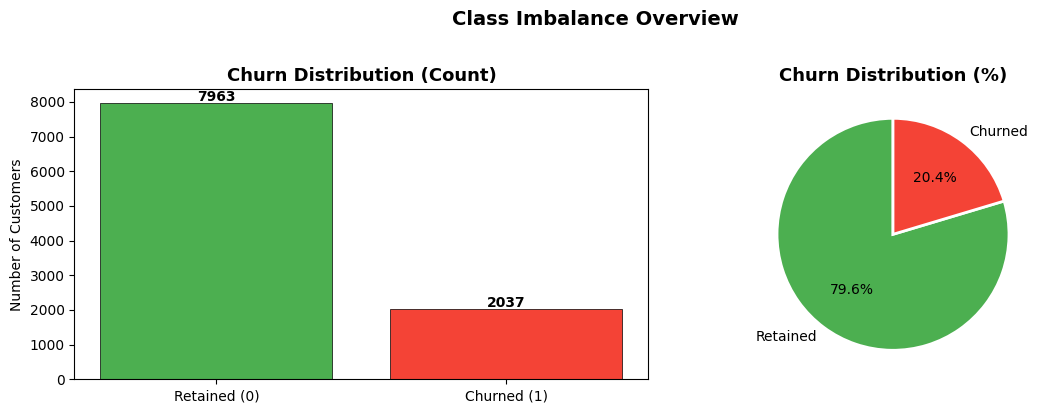

Class imbalance ratio — Retained:Churned = 7963:2037 (20.4% churn)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count
churn_counts = df['Exited'].value_counts()
colors = ['#4CAF50', '#F44336']
axes[0].bar(['Retained (0)', 'Churned (1)'], churn_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Churn Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie
axes[1].pie(churn_counts.values, labels=['Retained', 'Churned'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Distribution (%)', fontsize=13, fontweight='bold')

plt.suptitle('Class Imbalance Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f"Class imbalance ratio — Retained:Churned = {churn_counts[0]}:{churn_counts[1]} ({churn_counts[1]/len(df)*100:.1f}% churn)")

### 3.2 Churn by Categorical Features

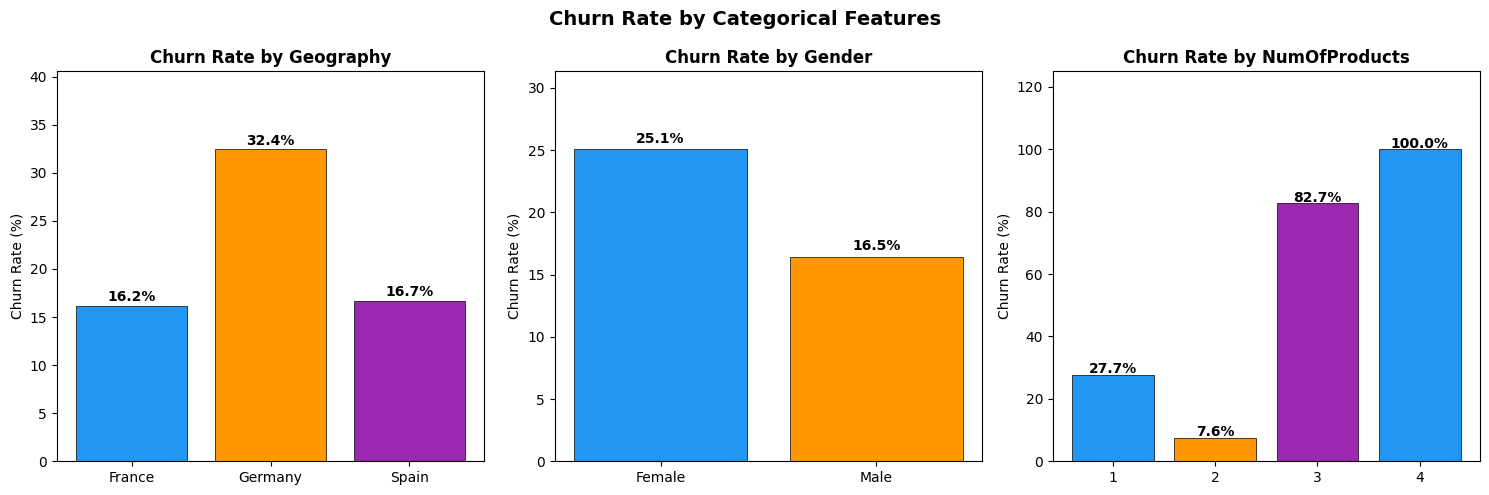

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['Geography', 'Gender', 'NumOfProducts']):
    ct = df.groupby(col)['Exited'].mean().reset_index()
    ct['Exited'] = ct['Exited'] * 100
    bars = ax.bar(ct[col].astype(str), ct['Exited'],
                  color=['#2196F3','#FF9800','#9C27B0'][:len(ct)],
                  edgecolor='black', linewidth=0.5)
    ax.set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, ct['Exited'].max() * 1.25)
    for bar, val in zip(bars, ct['Exited']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Churn by Numerical Features

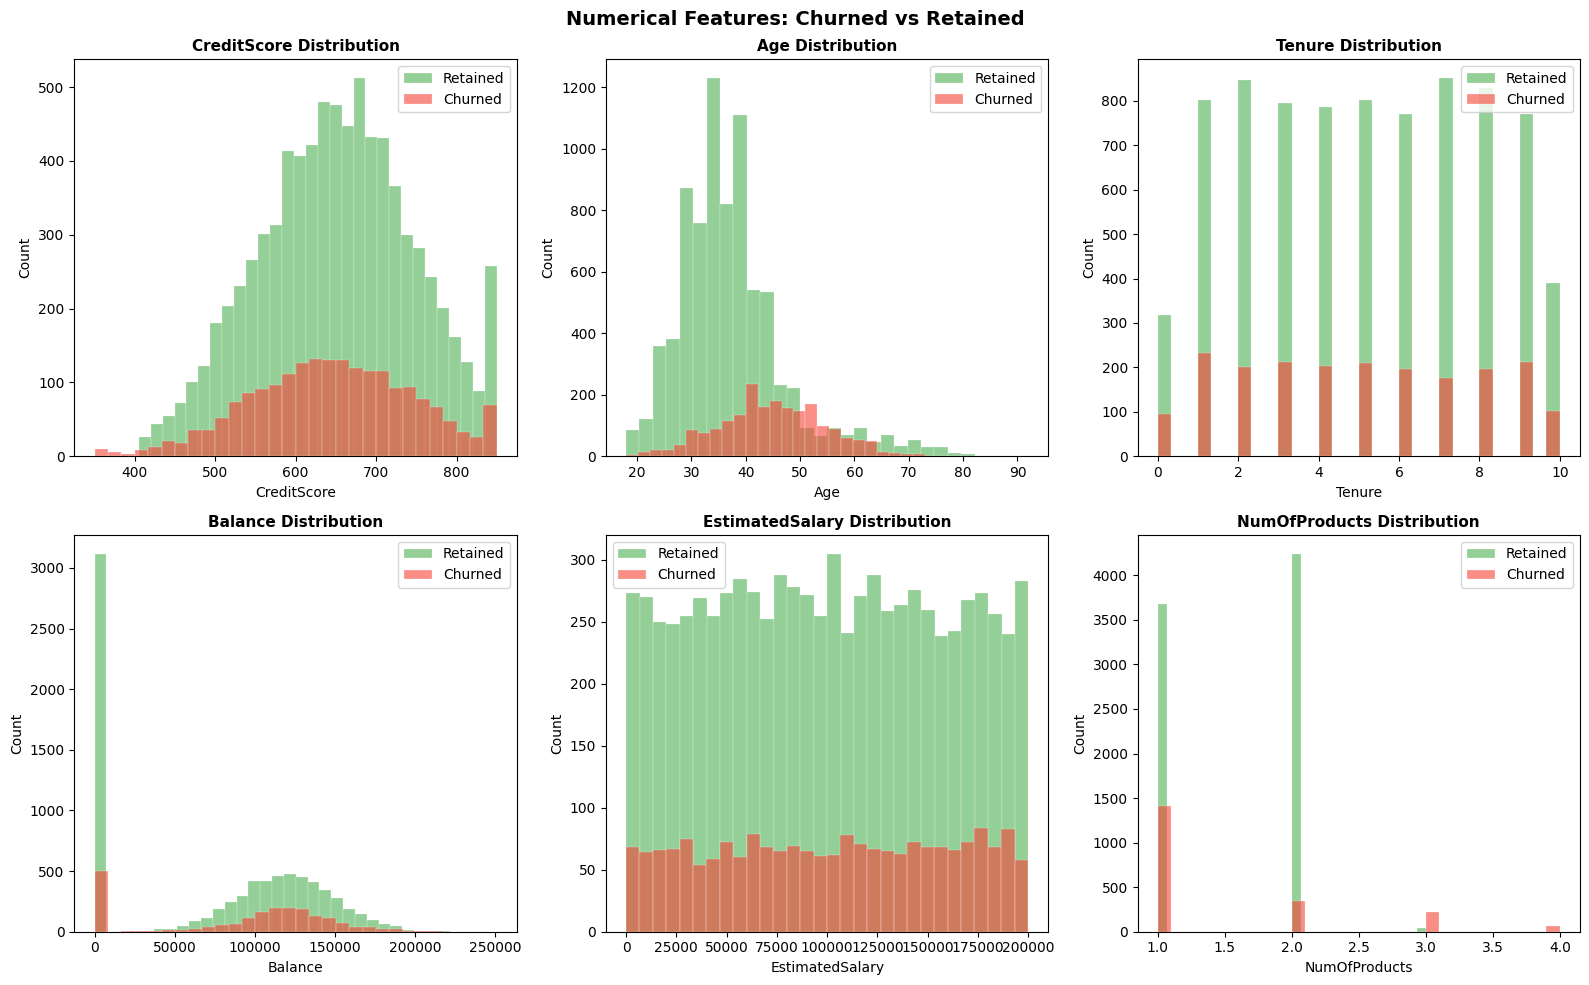

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'NumOfProducts']
colors_churn = {0: '#4CAF50', 1: '#F44336'}

for idx, col in enumerate(num_cols):
    for label, color in colors_churn.items():
        subset = df[df['Exited'] == label][col]
        axes[idx].hist(subset, bins=30, alpha=0.6, color=color,
                       label='Retained' if label==0 else 'Churned',
                       edgecolor='white', linewidth=0.3)
    axes[idx].set_title(f'{col} Distribution', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].legend()

plt.suptitle('Numerical Features: Churned vs Retained', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Correlation Heatmap

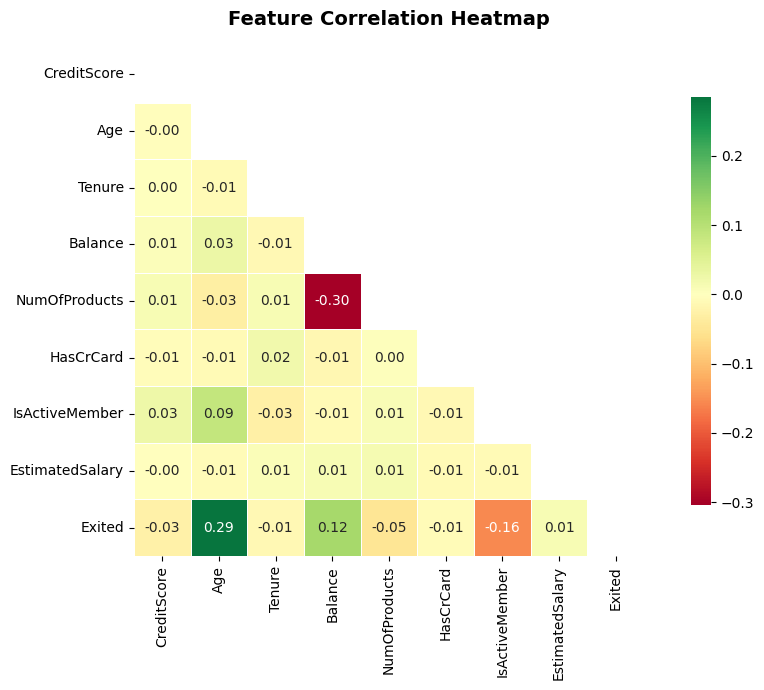

Top correlations with Exited:
Age                0.285
IsActiveMember     0.156
Balance            0.119
NumOfProducts      0.048
CreditScore        0.027
Tenure             0.014
EstimatedSalary    0.012
HasCrCard          0.007
Name: Exited, dtype: float64


In [18]:
plt.figure(figsize=(10, 7))
numeric_df = df.select_dtypes(include=[np.number]).drop(['RowNumber', 'CustomerId'], axis=1)
corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("Top correlations with Exited:")
print(corr['Exited'].drop('Exited').abs().sort_values(ascending=False).round(3))

## 4. Data Preprocessing

### Key fixes vs original notebook:
- Drop `RowNumber`, `CustomerId`, `Surname` (not predictive)
- Use `pd.get_dummies` with `drop_first=True` correctly
- Apply `class_weight` to handle imbalance — this is the **main reason** for poor test performance

In [19]:
# Drop non-predictive columns
X = df.drop(['RowNumber', 'CustomerId', 'Surname', 'Exited'], axis=1)
y = df['Exited']

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Features shape: (10000, 10)
Target distribution:
 Exited
0    7963
1    2037
Name: count, dtype: int64


In [20]:
# One-hot encode Geography and Gender
X = pd.get_dummies(X, columns=['Geography', 'Gender'], drop_first=True, dtype=int)

print("Encoded feature columns:")
print(list(X.columns))
print("\nFeature matrix shape:", X.shape)
X.head()

Encoded feature columns:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']

Feature matrix shape: (10000, 11)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0


In [21]:
# Train-test split (stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTrain churn rate: {y_train.mean()*100:.1f}%")
print(f"Test churn rate:  {y_test.mean()*100:.1f}%")

Training set: 8000 samples
Test set:     2000 samples

Train churn rate: 20.4%
Test churn rate:  20.3%


In [22]:
# Feature Scaling
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc  = sc.transform(X_test)

print("Scaling applied. Train mean (should be ~0):", X_train_sc.mean().round(4))
print("Train std  (should be ~1):", X_train_sc.std().round(4))

Scaling applied. Train mean (should be ~0): -0.0
Train std  (should be ~1): 1.0


In [23]:
# Compute class weights to handle imbalance
# This tells the model to penalize missing a churn more than missing a retention
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights_array[0], 1: class_weights_array[1]}
print(f"Class weights: {class_weight_dict}")
print(f"  → Churned (1) gets {class_weight_dict[1]:.2f}x more penalty — fixes imbalance issue")

Class weights: {0: np.float64(0.6279434850863422), 1: np.float64(2.4539877300613497)}
  → Churned (1) gets 2.45x more penalty — fixes imbalance issue


## 5. Build Improved ANN Architecture

### Improvements over original:
| Issue in Original | Fix Applied |
|---|---|
| No BatchNormalization | Added after each Dense layer |
| High learning rate (0.01) | Reduced to 0.001 + ReduceLROnPlateau |
| No class weighting | `class_weight` passed to `fit()` |
| `restore_best_weights=False` | Set to `True` — keeps best epoch |
| No input_dim specified | Explicit `input_dim` on first layer |
| Only accuracy metric | Added AUC metric during training |

In [24]:
def build_model(input_dim):
    model = Sequential([
        # Input + first hidden layer
        Dense(64, input_dim=input_dim),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(0.3),

        # Second hidden layer
        Dense(32),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(0.2),

        # Third hidden layer
        Dense(16),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(0.1),

        # Output layer
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

model = build_model(input_dim=X_train_sc.shape[1])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,617 (14.13 KB)

 Non-trainable params: 224 (896.00 B)

## 6. Train the Model

In [25]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_auc',
    patience=15,
    mode='max',
    restore_best_weights=True,   # <- was False in original
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

print("Starting training...")
history = model.fit(
    X_train_sc, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    class_weight=class_weight_dict,   # <- handles imbalance
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("\nTraining complete!")

Starting training...
Epoch 1/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.4759 - auc: 0.6731 - loss: 0.6692 - val_accuracy: 0.6769 - val_auc: 0.7971 - val_loss: 0.5957 - learning_rate: 0.0010
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6780 - auc: 0.7655 - loss: 0.5829 - val_accuracy: 0.7156 - val_auc: 0.8186 - val_loss: 0.5484 - learning_rate: 0.0010
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7214 - auc: 0.7942 - loss: 0.5535 - val_accuracy: 0.7287 - val_auc: 0.8339 - val_loss: 0.5171 - learning_rate: 0.0010
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7270 - auc: 0.8018 - loss: 0.5445 - val_accuracy: 0.7469 - val_auc: 0.8421 - val_loss: 0.4911 - learning_rate: 0.0010
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7319 - auc: 0.8074 - loss: 0.5373 - val_accuracy: 0.7550 - val_auc: 0.8474 - val_loss: 0.4817 - learning_rate: 0.0010
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step 

## 7. Training Visualizations

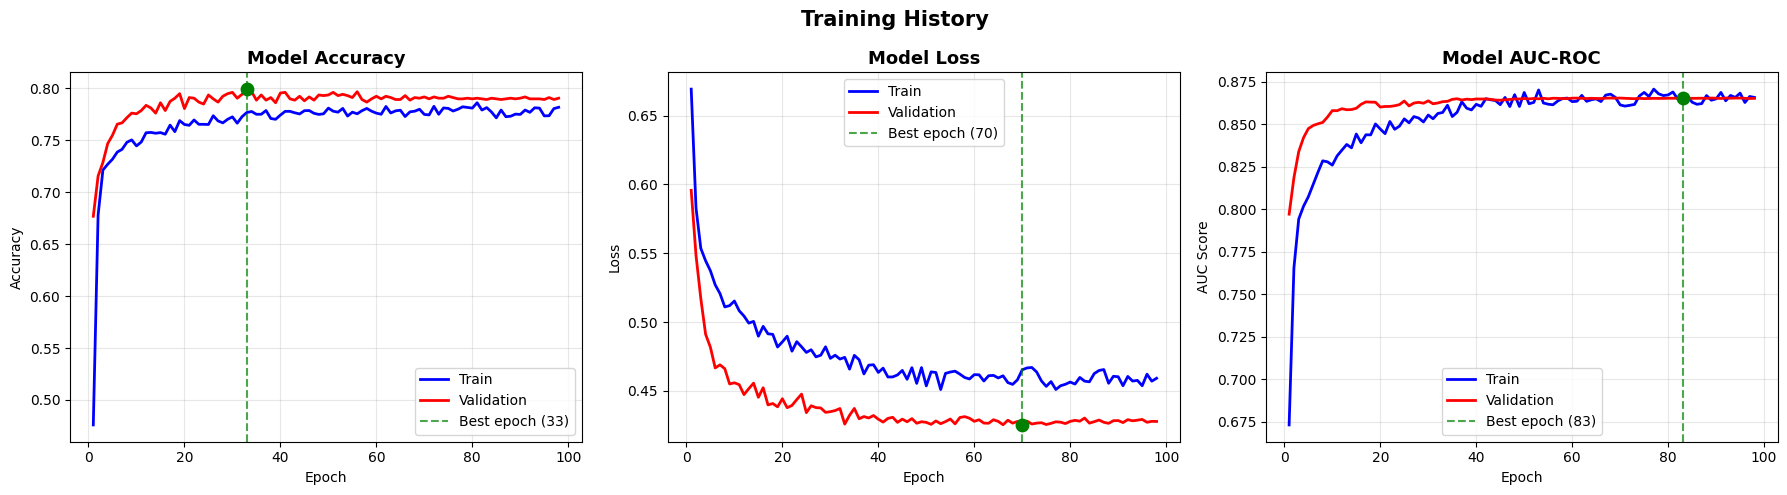

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = [
    ('accuracy', 'val_accuracy', 'Accuracy', 'Accuracy'),
    ('loss',     'val_loss',     'Loss',      'Loss'),
    ('auc',      'val_auc',      'AUC-ROC',   'AUC Score'),
]

for ax, (train_key, val_key, title, ylabel) in zip(axes, metrics):
    epochs_range = range(1, len(history.history[train_key]) + 1)
    ax.plot(epochs_range, history.history[train_key], 'b-', label='Train', linewidth=2)
    ax.plot(epochs_range, history.history[val_key],   'r-', label='Validation', linewidth=2)

    # Mark best epoch
    best_idx = np.argmax(history.history[val_key]) if title != 'Loss' else np.argmin(history.history[val_key])
    best_val = history.history[val_key][best_idx]
    ax.axvline(x=best_idx+1, color='green', linestyle='--', alpha=0.7, label=f'Best epoch ({best_idx+1})')
    ax.scatter([best_idx+1], [best_val], color='green', s=80, zorder=5)

    ax.set_title(f'Model {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Model Evaluation on Test Data

### Why we evaluate with multiple metrics:
With class imbalance, **accuracy alone is misleading**.  
A model that predicts "retained" for everyone gets 79.6% accuracy but detects 0 churners.  
Recall for class 1 (churn) is the most important business metric.

In [27]:
# Predict probabilities and labels
y_prob = model.predict(X_test_sc, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Core metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("=" * 45)
print("       TEST SET PERFORMANCE SUMMARY")
print("=" * 45)
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  Precision : {prec*100:.2f}%  (of predicted churners, how many were right)")
print(f"  Recall    : {rec*100:.2f}%  (of actual churners, how many did we catch)")
print(f"  F1 Score  : {f1*100:.2f}%  (harmonic mean of precision & recall)")
print(f"  AUC-ROC   : {roc_auc:.4f}  (1.0 = perfect, 0.5 = random)")
print("=" * 45)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

       TEST SET PERFORMANCE SUMMARY
  Accuracy  : 77.85%
  Precision : 47.31%  (of predicted churners, how many were right)
  Recall    : 77.89%  (of actual churners, how many did we catch)
  F1 Score  : 58.87%  (harmonic mean of precision & recall)
  AUC-ROC   : 0.8640  (1.0 = perfect, 0.5 = random)

Detailed Classification Report:
              precision    recall  f1-score   support

    Retained       0.93      0.78      0.85      1593
     Churned       0.47      0.78      0.59       407

    accuracy                           0.78      2000
   macro avg       0.70      0.78      0.72      2000
weighted avg       0.84      0.78      0.80      2000



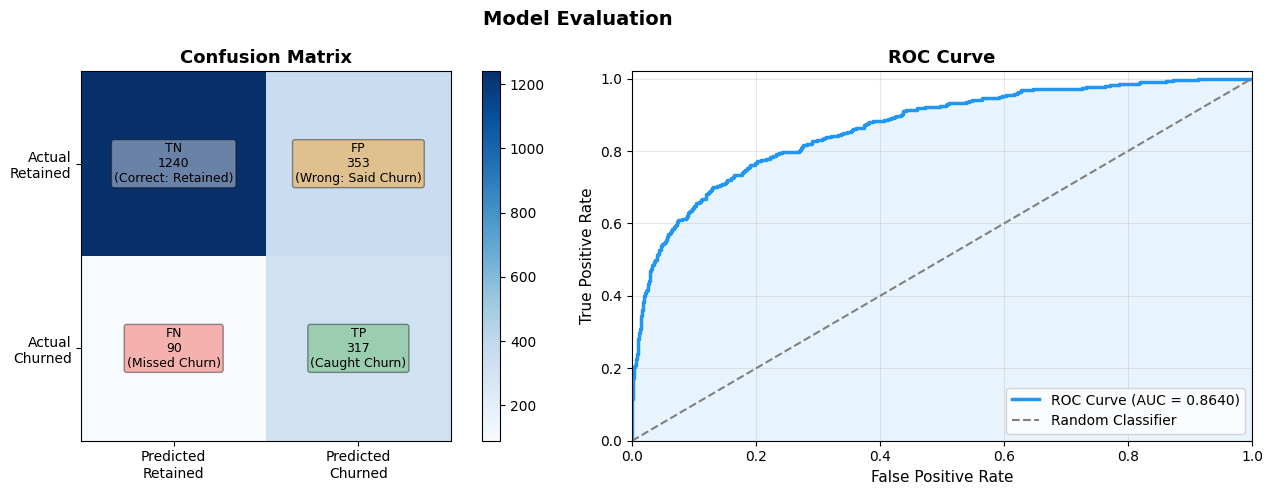

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Confusion Matrix ──
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

cm_labels = np.array([[f'TN\n{tn}\n(Correct: Retained)',  f'FP\n{fp}\n(Wrong: Said Churn)'],
                       [f'FN\n{fn}\n(Missed Churn)',        f'TP\n{tp}\n(Caught Churn)']])

im = axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=axes[0])
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Predicted\nRetained', 'Predicted\nChurned'], fontsize=10)
axes[0].set_yticklabels(['Actual\nRetained', 'Actual\nChurned'], fontsize=10)
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

colors_cm = [['#FFFFFF','#FF9800'],['#F44336','#4CAF50']]
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm_labels[i, j], ha='center', va='center',
                    fontsize=9, color='black',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor=colors_cm[i][j], alpha=0.4))

# ── ROC Curve ──
axes[1].plot(fpr, tpr, color='#2196F3', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.02])
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.1 Threshold Analysis — Find the Optimal Cutoff

Best threshold by F1 Score: 0.70
Threshold    0.7000
Accuracy     0.8610
Precision    0.6757
Recall       0.6093
F1           0.6408
Name: 12, dtype: float64


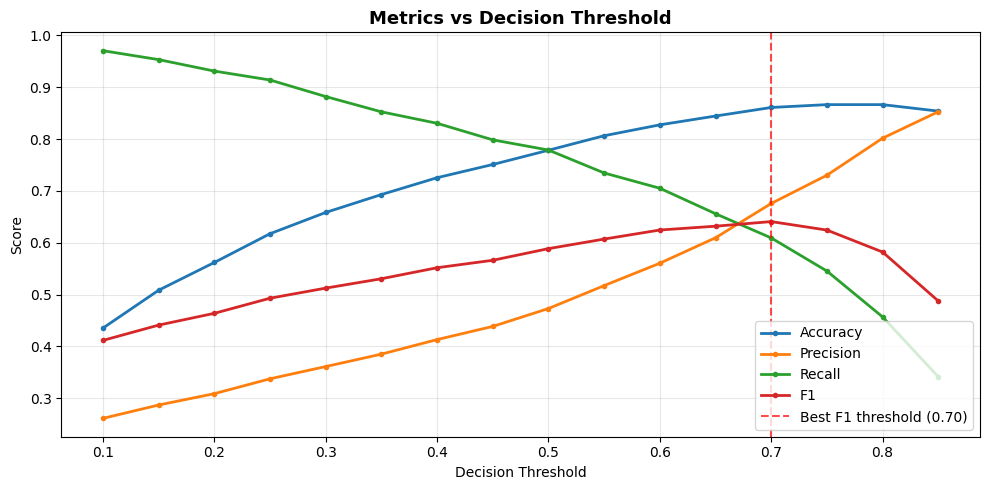

In [29]:
# Default threshold is 0.5, but we can tune it for better business outcome
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for thresh in thresholds:
    y_t = (y_prob >= thresh).astype(int)
    if y_t.sum() == 0:
        continue
    results.append({
        'Threshold': thresh,
        'Accuracy':  accuracy_score(y_test, y_t),
        'Precision': precision_score(y_test, y_t, zero_division=0),
        'Recall':    recall_score(y_test, y_t, zero_division=0),
        'F1':        f1_score(y_test, y_t, zero_division=0)
    })

thresh_df = pd.DataFrame(results)
best_f1_row = thresh_df.loc[thresh_df['F1'].idxmax()]
print(f"Best threshold by F1 Score: {best_f1_row['Threshold']:.2f}")
print(best_f1_row.round(4))

plt.figure(figsize=(10, 5))
for metric in ['Accuracy', 'Precision', 'Recall', 'F1']:
    plt.plot(thresh_df['Threshold'], thresh_df[metric], marker='o', markersize=3, label=metric, linewidth=2)
plt.axvline(x=best_f1_row['Threshold'], color='red', linestyle='--', alpha=0.7, label=f"Best F1 threshold ({best_f1_row['Threshold']:.2f})")
plt.xlabel('Decision Threshold'); plt.ylabel('Score')
plt.title('Metrics vs Decision Threshold', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Predict on Your Own Customer Query

Enter any customer's details below and get a churn prediction with probability.  
This is how you'd use the model in a real deployment.  

**Column reference:**  
`CreditScore` | `Geography` (France/Spain/Germany) | `Gender` (Male/Female)  
`Age` | `Tenure` (years at bank, 0–10) | `Balance`  
`NumOfProducts` (1–4) | `HasCrCard` (0/1) | `IsActiveMember` (0/1) | `EstimatedSalary`

In [31]:
def predict_customer(
    CreditScore, Geography, Gender, Age, Tenure,
    Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary
):
    """
    Predict churn probability for a single customer.
    Returns probability and label.
    """
    # Build input dict matching the training columns
    input_data = {
        'CreditScore':      [CreditScore],
        'Age':              [Age],
        'Tenure':           [Tenure],
        'Balance':          [Balance],
        'NumOfProducts':    [NumOfProducts],
        'HasCrCard':        [HasCrCard],
        'IsActiveMember':   [IsActiveMember],
        'EstimatedSalary':  [EstimatedSalary],
        'Geography_Germany':[1 if Geography == 'Germany' else 0],
        'Geography_Spain':  [1 if Geography == 'Spain'   else 0],
        'Gender_Male':      [1 if Gender    == 'Male'    else 0],
    }
    input_df = pd.DataFrame(input_data)

    # Ensure column order matches training data
    input_df = input_df[X.columns]

    # Scale
    input_scaled = sc.transform(input_df)

    # Predict
    prob = model.predict(input_scaled, verbose=0)[0][0]
    label = 'CHURN ⚠️' if prob >= 0.5 else 'STAY ✅'
    risk = 'HIGH' if prob >= 0.7 else ('MEDIUM' if prob >= 0.4 else 'LOW')

    print("=" * 50)
    print("        CUSTOMER CHURN PREDICTION")
    print("=" * 50)
    print(f"  Churn Probability : {prob*100:.1f}%")
    print(f"  Prediction        : {label}")
    print(f"  Risk Level        : {risk}")
    print("=" * 50)

    # Visual probability bar
    filled = int(prob * 30)
    bar_color = '🟥' if prob >= 0.7 else ('🟧' if prob >= 0.4 else '🟩')
    bar = bar_color * filled + '⬜' * (30 - filled)
    print(f"  [{bar}]  {prob*100:.1f}%")
    print("=" * 50)

    return prob, label

# ─── TEST QUERY 1: High risk customer ───
print(">>> High Risk Customer (Germany, inactive, 3 products):")
predict_customer(
    CreditScore=500,
    Geography='Germany',
    Gender='Female',
    Age=45,
    Tenure=3,
    Balance=120000,
    NumOfProducts=3,
    HasCrCard=1,
    IsActiveMember=0,
    EstimatedSalary=80000
)

>>> High Risk Customer (Germany, inactive, 3 products):
        CUSTOMER CHURN PREDICTION
  Churn Probability : 97.3%
  Prediction        : CHURN ⚠️
  Risk Level        : HIGH
  [🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥⬜]  97.3%


(np.float32(0.973243), 'CHURN ⚠️')

In [32]:
# ─── TEST QUERY 2: Low risk customer ───
print(">>> Low Risk Customer (France, active, 2 products):")
predict_customer(
    CreditScore=750,
    Geography='France',
    Gender='Male',
    Age=35,
    Tenure=7,
    Balance=50000,
    NumOfProducts=2,
    HasCrCard=1,
    IsActiveMember=1,
    EstimatedSalary=95000
)

>>> Low Risk Customer (France, active, 2 products):
        CUSTOMER CHURN PREDICTION
  Churn Probability : 3.9%
  Prediction        : STAY ✅
  Risk Level        : LOW
  [🟩⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜]  3.9%


(np.float32(0.039125554), 'STAY ✅')

In [33]:
# ─── EDIT THIS to test YOUR OWN customer ───
print(">>> Your Custom Query:")
predict_customer(
    CreditScore=620,       # ← change these values
    Geography='Spain',     # France / Spain / Germany
    Gender='Male',         # Male / Female
    Age=40,
    Tenure=5,
    Balance=75000,
    NumOfProducts=1,
    HasCrCard=1,           # 0 or 1
    IsActiveMember=1,      # 0 or 1
    EstimatedSalary=110000
)

>>> Your Custom Query:
        CUSTOMER CHURN PREDICTION
  Churn Probability : 32.9%
  Prediction        : STAY ✅
  Risk Level        : LOW
  [🟩🟩🟩🟩🟩🟩🟩🟩🟩⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜⬜]  32.9%


(np.float32(0.32872328), 'STAY ✅')

## 10. Summary & Key Improvements

### What was wrong with the original model:
| Problem | Impact | Fix |
|---|---|---|
| No class weights | Model ignored minority (churn) class → poor recall | `class_weight='balanced'` |
| `restore_best_weights=False` | Final epoch weights, not the best ones | Set to `True` |
| Learning rate too high (0.01) | Unstable training, overshooting | 0.001 + ReduceLROnPlateau |
| No BatchNormalization | Slower convergence, covariate shift | Added after each Dense |
| Only accuracy metric | Misleading with imbalanced data | AUC + F1 + Recall tracked |
| No stratified split | Test set might not reflect true distribution | `stratify=y` added |

### Business Interpretation:
- **Recall (churn class)** is the most important metric — catching real churners early is valuable
- **Germany + Inactive members + 3 products** = highest risk segment  
- The threshold tuning cell lets you trade off precision vs recall based on business need